## **Inference Notebook for Clustering and Classification using Credit Card Spending Data**

#### By: John Adrian T. Ada

---
### **Abstract** 

---

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import math

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, 
                            silhouette_samples, 
                            calinski_harabasz_score, 
                            davies_bouldin_score)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

### **Methods**


---
### **0. Dataset Information**

Dataset and Source: Credit Card Dataset for Clustering (Uploaded by Arjun Bhasin on Kaggle)

https://www.kaggle.com/datasets/arjunbhasin2013/ccdata 


The dataset used summarizes the usage behavior of 8950 active credit card holders over a six-month period with 18 behavioral variables. The following is the Data Dictionary for Credit Card dataset:

| Column Name | Description |
|---|---|
| CUST_ID | Identification of Credit Card holder (Categorical) |
| BALANCE | Balance amount left in their account to make purchases |
| BALANCE_FREQUENCY | How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated) |
| PURCHASES | Amount of purchases made from account |
| ONEOFF_PURCHASES | Maximum purchase amount done in one-go |
| INSTALLMENTS_PURCHASES | Amount of purchase done in installment |
| CASH_ADVANCE | Cash in advance given by the user |
| PURCHASES_FREQUENCY | How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased) |
| ONEOFFPURCHASESFREQUENCY | How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased) |
| PURCHASESINSTALLMENTSFREQUENCY | How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done) |
| CASHADVANCEFREQUENCY | How frequently the cash in advance being paid |
| CASHADVANCETRX | Number of Transactions made with "Cash in Advanced" |
| PURCHASES_TRX | Number of purchase transactions made |
| CREDIT_LIMIT | Limit of Credit Card for user |
| PAYMENTS | Amount of Payment done by user |
| MINIMUM_PAYMENTS | Minimum amount of payments made by user |
| PRCFULLPAYMENT | Percent of full payment paid by user |
| TENURE | Tenure of credit card service for user |

In this project, it was used for consumer segmentation using unsupervised Machine Learning such as Clustering to determine different types of consumers before using Supervised Machine Learning to predict the labels determined from clustering. 

---
### **1. Data Loading, Exploratory Data Analysis and Pre-processing**


In [4]:
df = pd.read_csv(r'../cc-dataset/CC GENERAL.csv')

print(df.columns)
df.head()

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


Some notes:
- No Negative Values for all columns, as expected
- High Standard Deviation, and thus high Variance, for most of the columns with a high range
- There are a missing values, seen in the count column. 
- Large disparity between the mean and median (50%) for the columns with a high range and high variance, suggesting that there are outliers. 

In [6]:
int_cols = list(df.select_dtypes(include=['int64']).columns)
for col in int_cols:
    print(col)
    print(df[col].unique())

CASH_ADVANCE_TRX
[  0   4   1   3   6  13   5  16  10   2  11   7  12  37  27  23  21  14
  40   8   9  26  15  18  28  24  20  17  22  31 123  52  51  62  19  25
  30  29  53  45  43  42 107  38  56  39  32  33  50  34  63  36 110  47
  48  71  35  93  80  44  61  46  49  69  41]
PURCHASES_TRX
[  2   0  12   1   8  64   5   3   6  26  11   9  92  17  13  45  14  41
  27  20  87  18   4  42  61  33   7  50  22  23  60  46  75  31  10  34
  81  25  85 217  19  52 216  97  24  77 130  90  44  39  15  30  36 123
 151  21 101  49  98  28  84  93  72  38  99  62  48  16  32  51  74  29
  59  76  47 126 229  40 103 121 157 114  53  83  43  54 222  66 141  37
  79  70  80 194 117 100 111  67 219  55 152 104 182  88  82  71  78  35
 122 105 108  69 175 135  91  65  68 119  63 140 113 358  58 248 129  56
  89  57 139 176 136 195  73 109 208 115 110 147 273 102 185 171 168 232
  95  86 148 112 128 254 198 298 154 116 142 131 347 204 200  94 118 344
 162 308 199 309  96 274 224 143 133 127 186]
T

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [8]:
null_df = pd.DataFrame({'Missing Values': df.isnull().sum(), 'Percentage': round(df.isnull().sum() / df.shape[0] * 100, 2)})

null_df.sort_values('Missing Values', ascending=False)

,Missing Values,Percentage
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01
BALANCE,0,0.00
CUST_ID,0,0.00
BALANCE_FREQUENCY,0,0.00
PURCHASES,0,0.00
CASH_ADVANCE,0,0.00
PURCHASES_FREQUENCY,0,0.00
ONEOFF_PURCHASES,0,0.00
INSTALLMENTS_PURCHASES,0,0.00


Most of the null values come from the Minimum Payments column. According to the Data Dictionary, it is the Mininum Payments made by a user. By definition, it always has to be less than or equal to the Payments column. From the succeeding cells, Minimum Payments and Credit Limit, the two columns with null values, are continuous and right-skewed. This means that the Median, not the Mean, would be preferred for simple imputing if imputation is done later on. 

In [9]:
df[df.isnull().any(axis=1)].head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,C10056,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
56,C10058,3625.218146,1.000000,313.27,313.27,0.0,668.468743,0.250000,0.250000,0.000000,0.416667,5,4,4000.0,0.000000,NaN,0.0,12
63,C10065,7.152356,0.090909,840.00,840.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1600.0,0.000000,NaN,0.0,12
93,C10098,1307.717841,1.000000,405.60,405.60,0.0,0.000000,0.166667,0.166667,0.000000,0.000000,0,2,2400.0,0.000000,NaN,0.0,12
94,C10099,2329.485768,1.000000,213.34,213.34,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,3,2400.0,0.000000,NaN,0.0,12
97,C10102,3505.671311,1.000000,0.00,0.00,0.0,1713.984305,0.000000,0.000000,0.000000,0.500000,6,0,4000.0,0.000000,NaN,0.0,12


Since CUST_ID is the unique identifier for the dataset, duplicate records can be checked using this column

In [10]:
print(f"Number of duplicate records: {df['CUST_ID'].duplicated().sum()}")

Number of duplicate records: 0


##### **Distribution**

In [11]:
def plot_all_features_grid(dataframe, max_cols=9):
    """
    Calculates a grid and plots all features in a single large figure.
    Works for any number of dimensions by dynamically calculating grid shape.
    
    Parameters:
    - dataframe: The pandas DataFrame containing features to plot.
    - max_cols: The maximum number of columns for the plot grid.
    """
    print("Generating dynamic grid plot...")
    num_features = len(dataframe.columns)
    
    # Guard clause in case an empty dataframe is passed
    if num_features == 0:
        print("No features to plot.")
        return

    # Don't create more grid columns than actual features
    grid_cols = min(num_features, max_cols)
    grid_rows = math.ceil(num_features / grid_cols)
    
    # Dynamically scale the figure size (approx 3x2.5 inches per subplot)
    fig_width = grid_cols * 3
    fig_height = grid_rows * 2.5
    
    fig, axes = plt.subplots(nrows=grid_rows, ncols=grid_cols, figsize=(fig_width, fig_height))
    
    # Flatten axes array for easy iteration (handles 1x1 case safely)
    if num_features == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, col in enumerate(dataframe.columns):
        # Plot on the specific subplot axis
        sns.histplot(dataframe[col], kde=True, bins=20, ax=axes[i], color='coral')
        
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("") # Remove x-labels to save space
        axes[i].set_ylabel("") # Remove y-labels to save space
        axes[i].tick_params(axis='both', which='major', labelsize=8)

    # Clean up: hide any extra empty subplots if the grid isn't perfectly filled
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    # Adjust layout to prevent title/tick overlap
    plt.tight_layout()
    plt.show()

Generating dynamic grid plot...


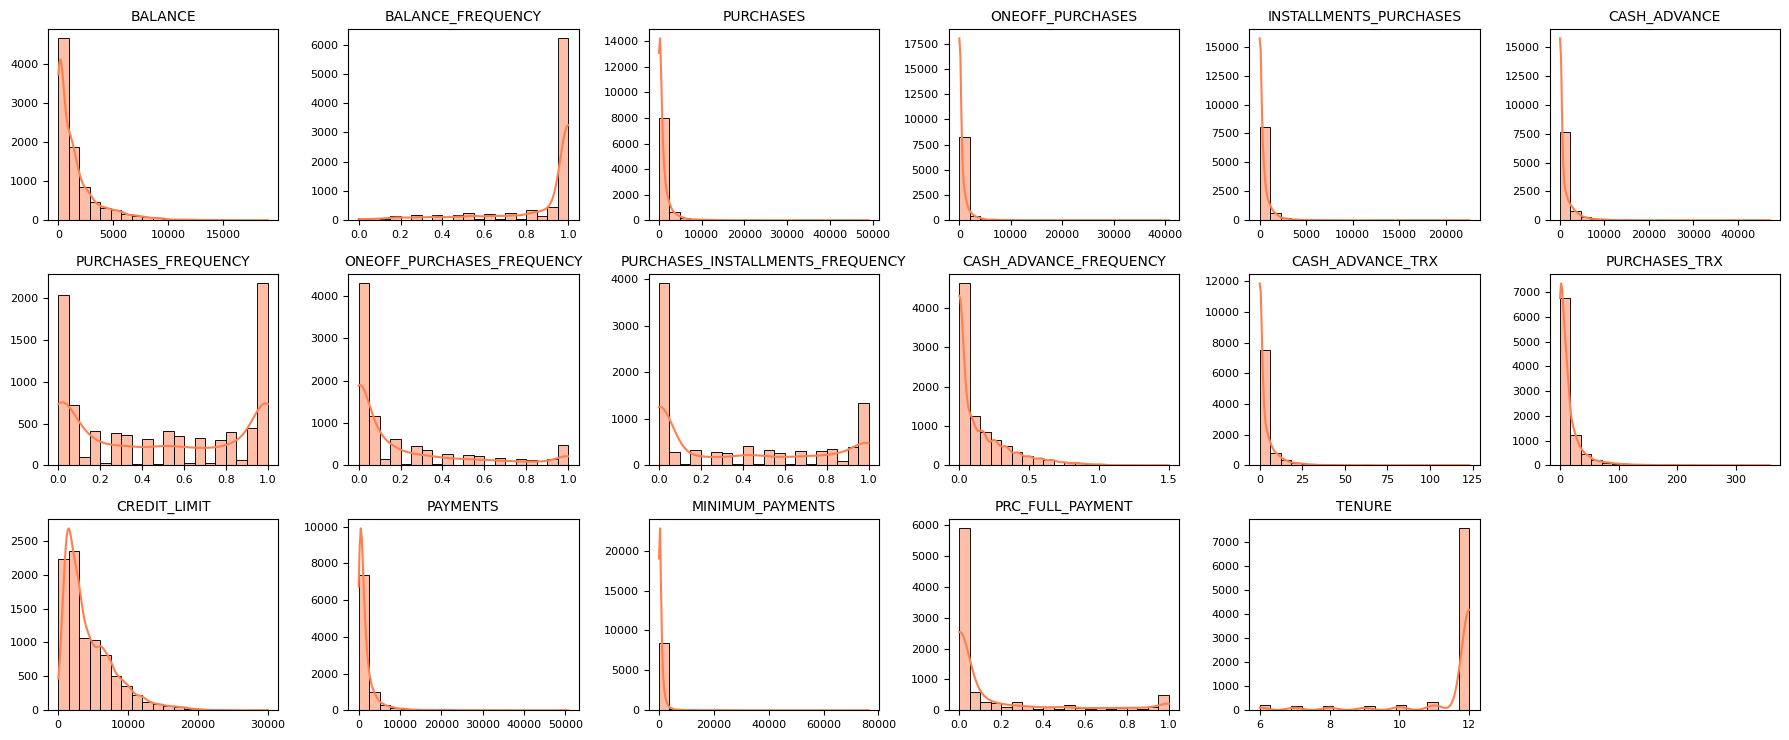

In [12]:
plot_all_features_grid(df.drop('CUST_ID', axis=1), 6)

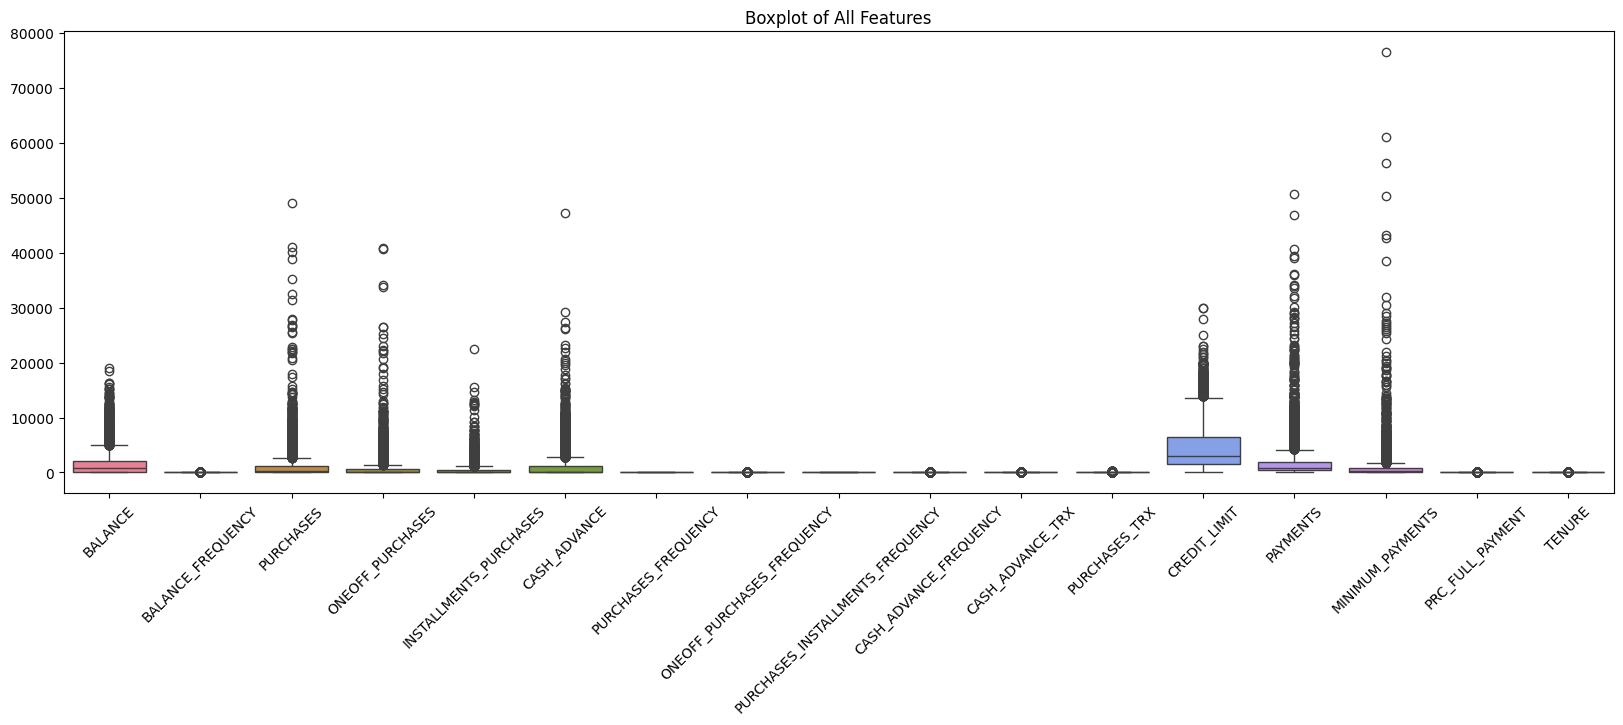

In [13]:
numerical_cols = df.select_dtypes(include=["float64", "int64"])
plt.figure(figsize=(20, 6))
sns.boxplot(numerical_cols)
plt.xticks(rotation=45)  
plt.title("Boxplot of All Features")
plt.show()

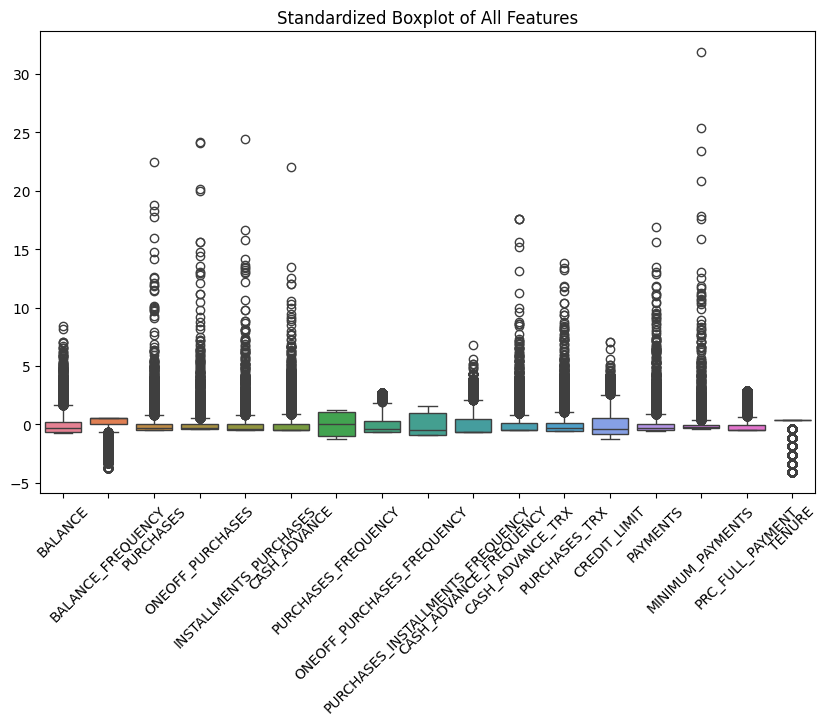

In [14]:
#standardized
numerical_cols = df.select_dtypes(include=["float64", "int64"])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_cols)
scaled_df = pd.DataFrame(scaled_data, columns=numerical_cols.columns)

plt.figure(figsize=(10, 6))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=45)  
plt.title("Standardized Boxplot of All Features")
plt.show()

Most of the features are right-skewed, particularly features relating to money or wealth such as Purchases, Balance, Credit Limit, and Payments. Thus, it is expected that there are significantly less high spenders due to the low frequency (y-axis) of the aforementioned features that exhibit the higher values (x-axis) of their range. 

##### **Correlation Heatmap**

<Axes: >

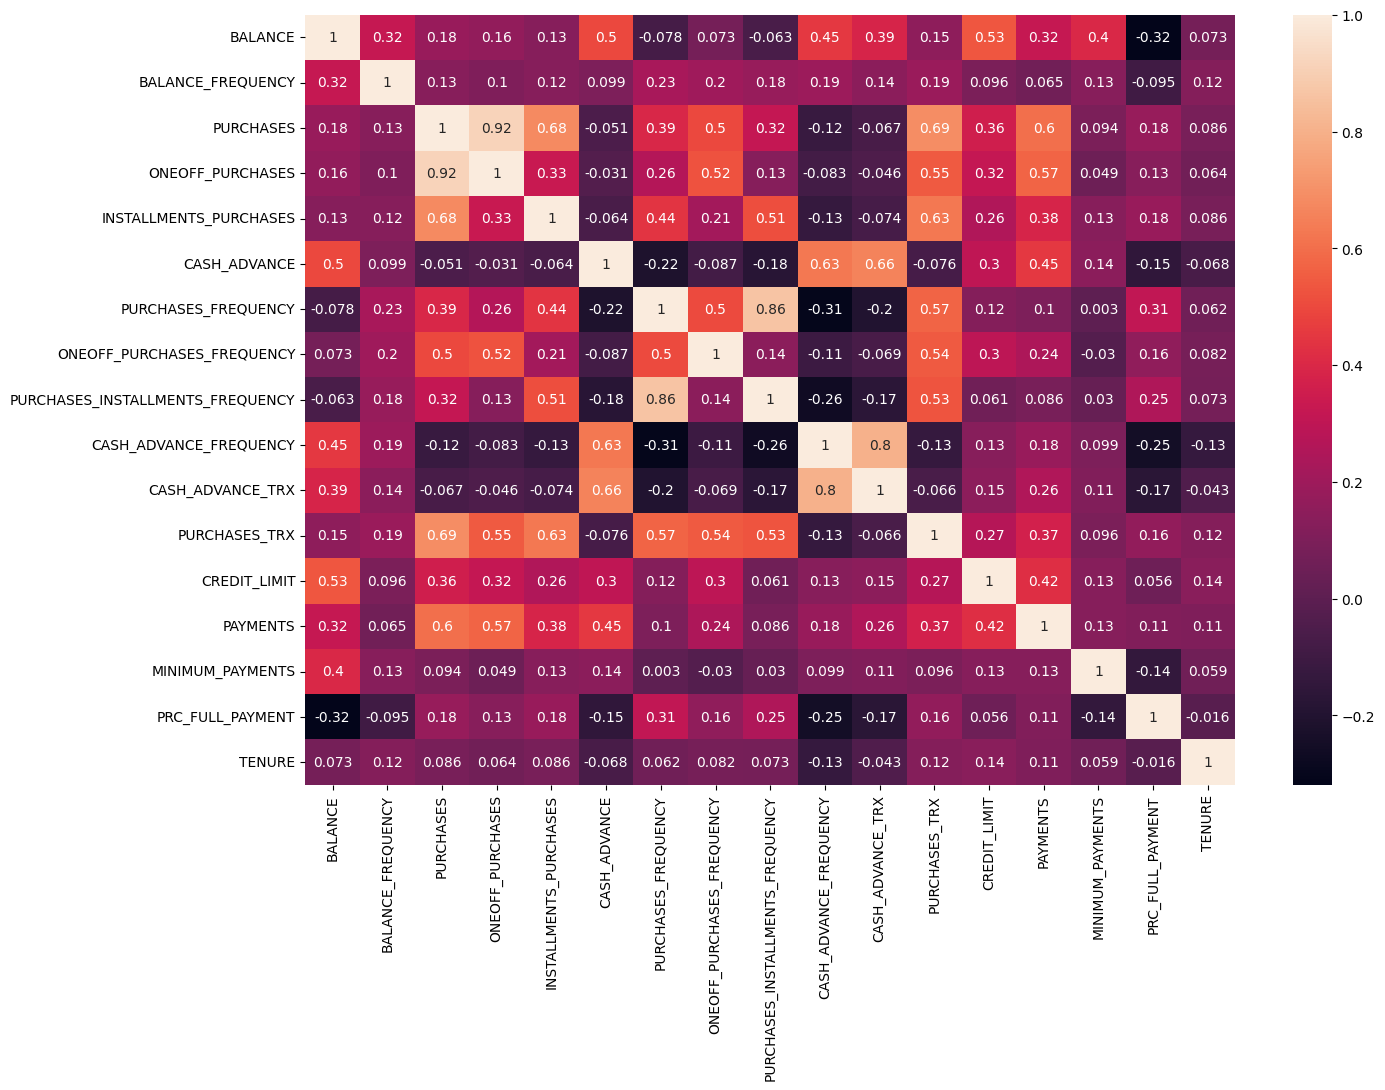

In [15]:
#heatmap correlation
plt.figure(figsize=(15, 10))
sns.heatmap(numerical_cols.corr(), annot=True)

In [16]:
#print max correlation coefficient that are less than 1
masked_corr = numerical_cols.corr().replace(1.0, np.nan)
print(masked_corr.max().sort_values(ascending=False))

PURCHASES                           0.916845
ONEOFF_PURCHASES                    0.916845
PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
PURCHASES_FREQUENCY                 0.862934
CASH_ADVANCE_TRX                    0.799561
CASH_ADVANCE_FREQUENCY              0.799561
PURCHASES_TRX                       0.689561
INSTALLMENTS_PURCHASES              0.679896
CASH_ADVANCE                        0.656498
PAYMENTS                            0.603264
ONEOFF_PURCHASES_FREQUENCY          0.544869
BALANCE                             0.531283
CREDIT_LIMIT                        0.531283
MINIMUM_PAYMENTS                    0.398684
BALANCE_FREQUENCY                   0.322412
PRC_FULL_PAYMENT                    0.305802
TENURE                              0.139167
dtype: float64


<Axes: >

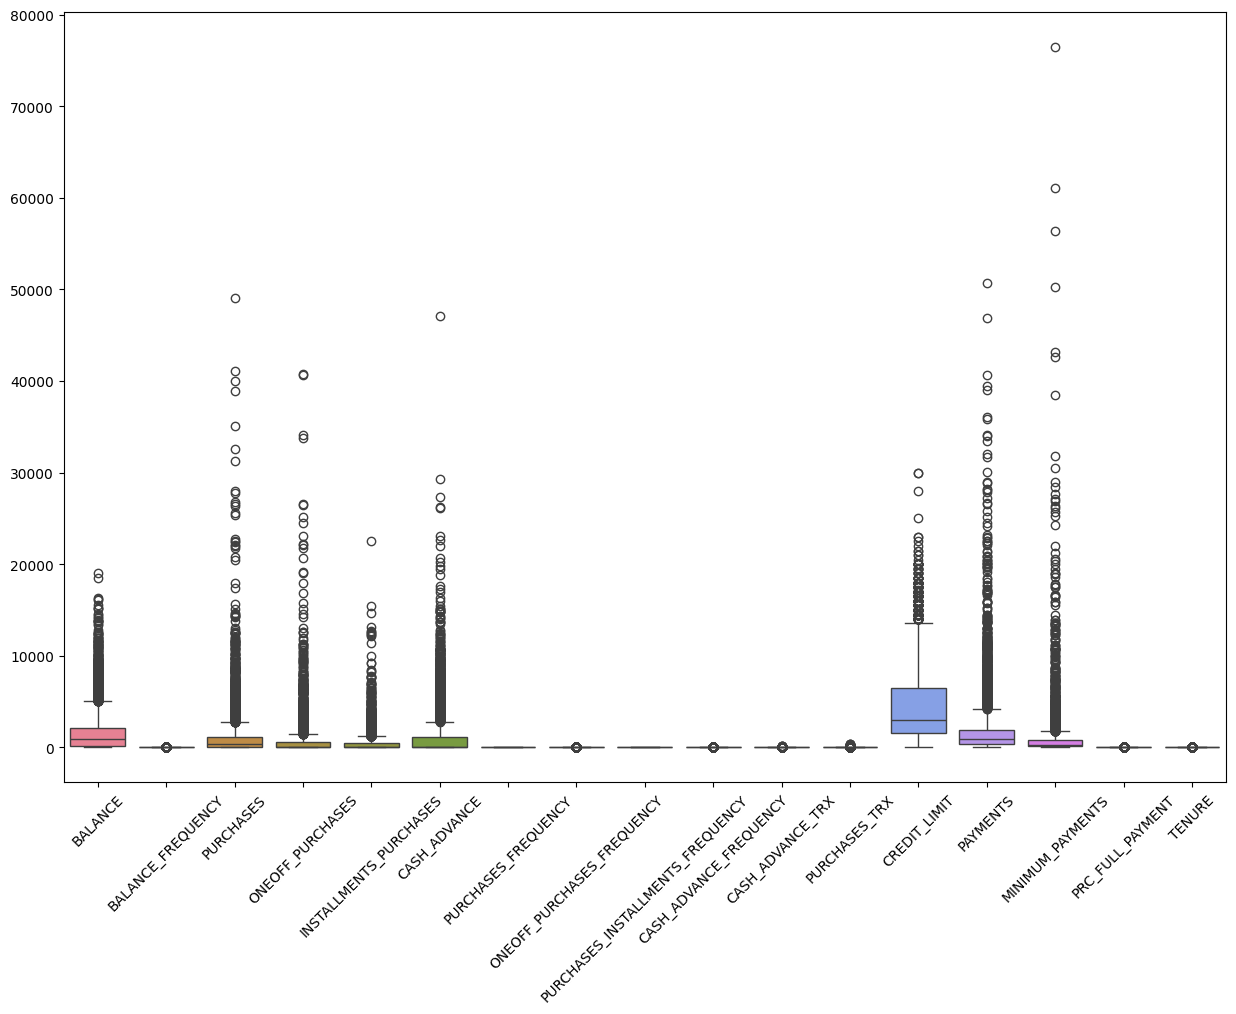

In [37]:
plt.figure(figsize=(15, 10))
plt.xticks(rotation=45)
sns.boxplot(data=numerical_cols)

Plenty of outliers, plenty of right skewed features as seen in the table of Descriptive Statistics and Bar plots. 

In [29]:
#df = df.drop(['CUST_ID'], axis=1)
df.dropna(inplace=True)

---
### **2. Dimensionality Reduction and Clustering**


Dimensionality reduction is typically a pre-cursor to Clustering, hence it is used here to check if it is needed. Though, some of the results from the Exploratory Data Analysis part may have already shown that it isn't necessary. 

In [26]:
#import PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [32]:
scaled_df = StandardScaler().fit_transform(df)

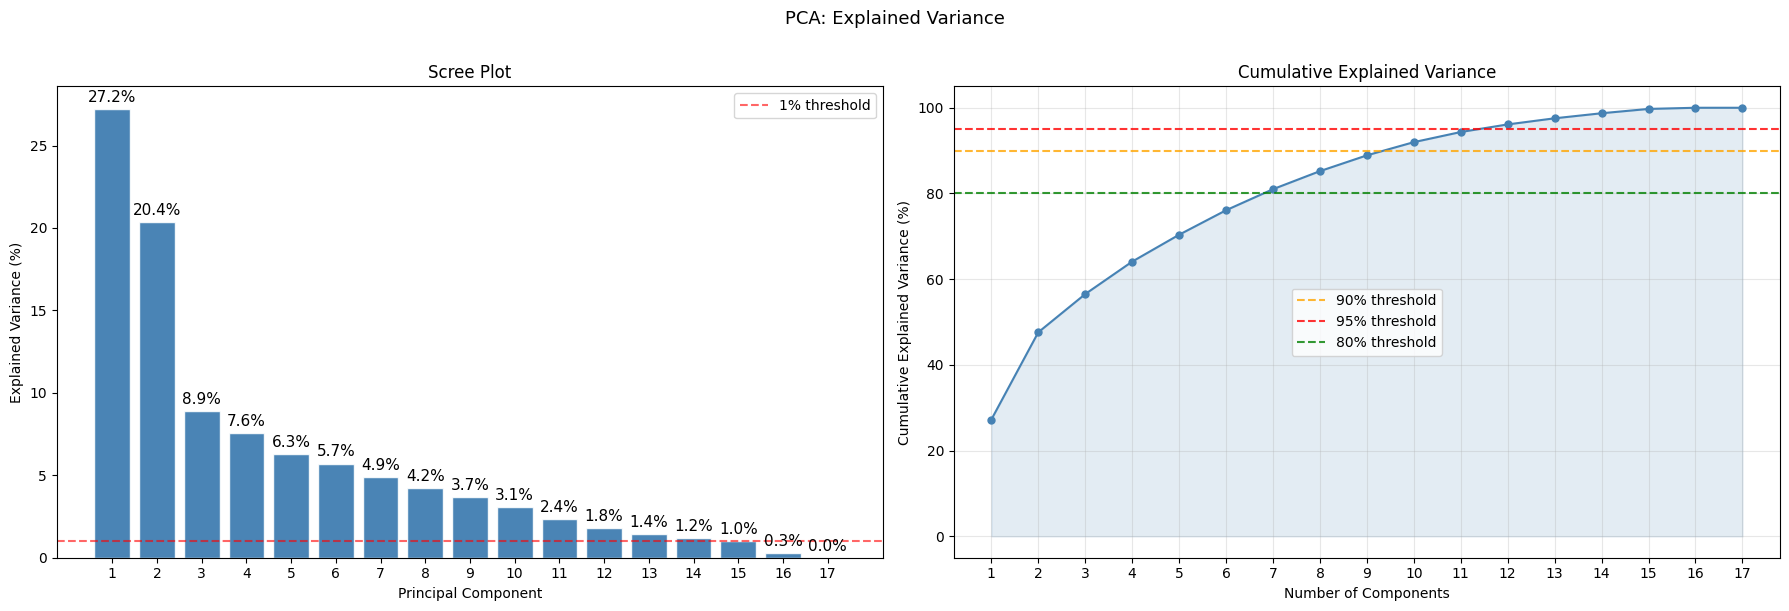

EXPLAINED VARIANCE BY COMPONENT

  PC01: 27.23%  |  Cumulative:  27.23%
  PC02: 20.37%  |  Cumulative:  47.61%
  PC03:  8.92%  |  Cumulative:  56.52%
  PC04:  7.57%  |  Cumulative:  64.10%
  PC05:  6.28%  |  Cumulative:  70.37%
  PC06:  5.71%  |  Cumulative:  76.09%
  PC07:  4.92%  |  Cumulative:  81.00%
  PC08:  4.21%  |  Cumulative:  85.21%
  PC09:  3.68%  |  Cumulative:  88.90%
  PC10:  3.08%  |  Cumulative:  91.98%

  Components needed to explain 80% of variance: 7
  Components needed to explain 90% of variance: 10
  Components needed to explain 95% of variance: 12
  Feature count: 17
  Compression ratio (90% threshold): 10/30 = 33.3%
  For Reference, the number of features (excluding CUST_ID) is 17


In [34]:
pca = PCA(random_state=42)
pca.fit(scaled_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scree plot
components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
axes[0].bar(
    components, pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)

bars = axes[0].bar(
    components, pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)

axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.6, label='1% threshold')
axes[0].legend()

axes[0].set_xticks(components)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, color='black', fontsize=11)

# Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(components, cumvar, 'o-', color='steelblue', markersize=5)
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.8, label='90% threshold')
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.8, label='95% threshold')
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.8, label='80% threshold')
axes[1].fill_between(components, cumvar, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[1].set_xticks(components)

plt.suptitle('PCA: Explained Variance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Report
print("EXPLAINED VARIANCE BY COMPONENT\n")
cumulative = 0
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    cumulative += var
    print(f"  PC{i+1:02d}: {var*100:5.2f}%  |  Cumulative: {cumulative*100:6.2f}%")

n_80 = np.argmax(cumvar >= 80) + 1
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
print()
print(f"  Components needed to explain 80% of variance: {n_80}")
print(f"  Components needed to explain 90% of variance: {n_90}")
print(f"  Components needed to explain 95% of variance: {n_95}")
print(f"  Feature count: {scaled_df.shape[1]}")
print(f"  Compression ratio (90% threshold): {n_90}/30 = {n_90/30:.1%}")
print(f"  For Reference, the number of features (excluding CUST_ID) is {scaled_df.shape[1]}")

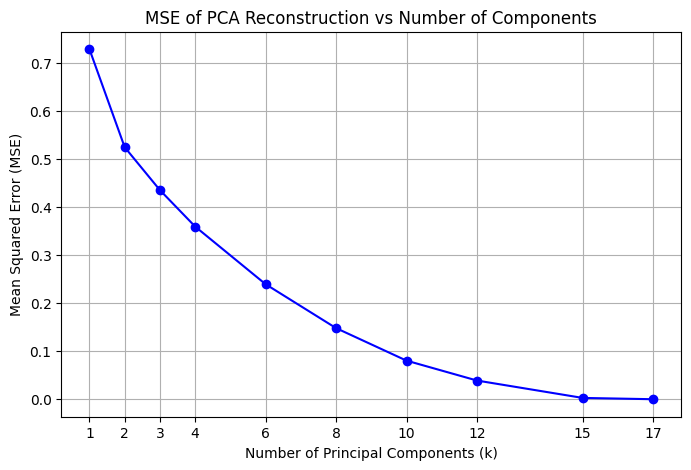

In [39]:
# PCA Reconstruction
k_values = [1, 2, 3, 4, 6, 8, 10, 12, 15, 17]
mse_list = []
mse_k2 = None

for k in k_values:
    pca = PCA(n_components=k, random_state=42)
    transformed = pca.fit_transform(scaled_df)
    reconstructed = pca.inverse_transform(transformed)
    
    mse_per_row = np.mean((scaled_df - reconstructed) ** 2, axis=1)
    mse = np.mean(mse_per_row)
    mse_list.append(mse)
    
    if k == 2:
        mse_k2 = mse_per_row

plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_list, marker='o', linestyle='-', color='b')
plt.title('MSE of PCA Reconstruction vs Number of Components')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(k_values)
plt.grid(True)

As expected, given the Heatmap of the Correlation Matrix in Chapter 1, Principal Component Analysis (PCA) cannot be used for dimensionality reduction due to the low cumulative explained variance if only a small number of principal components are selected. Plenty of the features are not highly correlated. To reach the 80% threshold, seven components or 41% of the components would be needed. Forcing the use of PCA for dimensionality reduction would also hurt interpretability. 

---
### **3. Cluster Profiles**


---
### **4. Multiple Model Training for Classification**


---
### **5. Performance Metrics**


---
### **6. Conclusion**
